In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("50_Startups.csv")

In [3]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
dataset=pd.get_dummies(dataset,dtype=int,drop_first='True')

In [5]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [7]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']]

In [8]:
independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [9]:
dependent=dataset[["Profit"]]

In [10]:
dependent

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(independent, dependent, test_size=0.30, random_state=0)

In [13]:
from sklearn.tree import DecisionTreeRegressor

In [96]:
#criterion='squared_error', splitter='best'(default) / criterion='friedman_mse', splitter='best'
#criterion='absolute_error', splitter='best' / criterion='poisson', splitter='best'
#criterion='squared_error', splitter='random' / criterion='friedman_mse', splitter='random'
#criterion='absolute_error', splitter='random' / criterion='poisson', splitter='random'
regressor=DecisionTreeRegressor(criterion='absolute_error', splitter='best')

In [97]:
regressor=regressor.fit(X_train,y_train) #execute this command with .fit and Model will be created and this model will be stored inside regressor

In [98]:
regressor

,criterion,'absolute_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [99]:
import matplotlib.pyplot as plt   #graph purpose

In [100]:
from sklearn import tree

[Text(0.46875, 0.9444444444444444, 'x[0] <= 64036.785\nabsolute_error = 34660.428\nsamples = 35\nvalue = 108733.99'),
 Text(0.203125, 0.8333333333333334, 'x[0] <= 8410.595\nabsolute_error = 19034.017\nsamples = 14\nvalue = 70628.735'),
 Text(0.3359375, 0.8888888888888888, 'True  '),
 Text(0.10416666666666667, 0.7222222222222222, 'x[0] <= 771.14\nabsolute_error = 12812.404\nsamples = 5\nvalue = 42559.73'),
 Text(0.0625, 0.6111111111111112, 'x[2] <= 22586.529\nabsolute_error = 9292.777\nsamples = 3\nvalue = 35673.41'),
 Text(0.041666666666666664, 0.5, 'x[1] <= 93585.035\nabsolute_error = 3443.16\nsamples = 2\nvalue = 39116.57'),
 Text(0.020833333333333332, 0.3888888888888889, 'absolute_error = 0.0\nsamples = 1\nvalue = 35673.41'),
 Text(0.0625, 0.3888888888888889, 'absolute_error = 0.0\nsamples = 1\nvalue = 42559.73'),
 Text(0.08333333333333333, 0.5, 'absolute_error = 0.0\nsamples = 1\nvalue = 14681.4'),
 Text(0.14583333333333334, 0.6111111111111112, 'x[2] <= 149509.199\nabsolute_error =

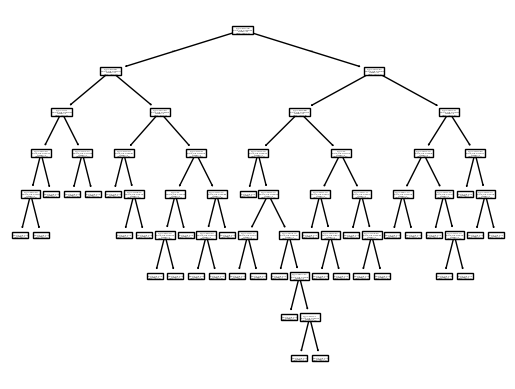

In [101]:
tree.plot_tree(regressor)  #input the model saved inside regressor

In [102]:
plt.show()

In [103]:
y_pred=regressor.predict(X_test)

In [104]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)
r_score

0.9377588818896423